# Data Preparation Functions
(thanks joel)

In [36]:
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

plt.rcParams["figure.figsize"] = (24, 12)

In [37]:
# Cropping Constants
BINARY_THRESHOLD = 1
RUN_THRESHOLD = 0.14
MIN_HEIGHT = 300

# Artifacts Constants
ARTIFACT_INTENSITY = 220

In [38]:
def load_image(image_path):
    img = cv2.imread(image_path, 1)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img_rgb

def crop_image(image_array, window_size):
    ultrasound_image = find_ultrasound_image(image_array)
    cropped_image = standardize_size(ultrasound_image, window_size)
    return cropped_image

def remove_artifacts(cropped_image):
    artifact_flags = cropped_image >= ARTIFACT_INTENSITY
    artifact_idx = np.where(artifact_flags)
    artifact_idx_list = []
    for i, y in enumerate(artifact_idx[0]):
        x = artifact_idx[1][i]
        artifact_idx_list.append((y, x, cropped_image[y, x]))
    artifact_idx_list.sort(key=lambda tup: tup[2], reverse=False)
    for y, x, _ in artifact_idx_list:
        local_region = cropped_image[(y-1):(y+2), (x-1):(x+2)]
        background_mean = np.mean(sorted(local_region.flatten())[:6])
        cropped_image[y, x] = background_mean
    return cropped_image

def find_ultrasound_image(image_array):
    binary_mask = np.zeros(image_array.shape)
    binary_mask[image_array > BINARY_THRESHOLD] = 1.
    
    row_mean = np.mean(binary_mask, axis=0)
    col_mean = np.mean(binary_mask, axis=1)
    
    row_runs = get_bidirectional_runs(row_mean)
    col_runs = get_bidirectional_runs(col_mean)
    
    row_indices = np.where(row_runs >= np.max(row_runs)*0.75)[0]
    left_bound = row_indices[0]
    right_bound = row_indices[-1]
    col_indices = np.where(col_runs >= np.max(col_runs)*0.75)[0]
    up_bound = col_indices[0]
    down_bound = max(col_indices[-1], up_bound + MIN_HEIGHT)
    cropped_image = image_array[up_bound:down_bound, left_bound:right_bound]
    
    return cropped_image

def standardize_size(ultrasound_image, window_size):
    resized_image = np.zeros(window_size)
    horizontal_boundary = int((window_size[1] - ultrasound_image.shape[1])/2)
    vertical_boundary = int((window_size[0] - ultrasound_image.shape[0])/2)
    resized_image[vertical_boundary:(vertical_boundary+ultrasound_image.shape[0]), 
                  horizontal_boundary:(horizontal_boundary+ultrasound_image.shape[1])] = ultrasound_image
    return resized_image

def get_bidirectional_runs(mean_vector):
    forward_runs = get_runs(mean_vector)
    backward_runs = get_runs(mean_vector[::-1])[::-1]
    bidirectional_runs = forward_runs + backward_runs
    return bidirectional_runs

def get_runs(numeric_vector):
    runs = np.empty(len(numeric_vector), dtype=np.int16)
    curr = 0
    for i, x in enumerate(numeric_vector):
        if x > RUN_THRESHOLD:
            curr += 1
        else:
            curr = 0
        runs[i] = curr
    return runs

def represents_int(s):
    try: 
        int(s)
        return True
    except ValueError:
        return False

# Data Preparation

In [39]:
import csv
import os
import pandas as pd

df=pd.read_csv(os.path.join('..','data', 'aggregate.csv'))

In [40]:
sample_id=df.sample_id
image=df.image
rows=len(image)

window_size = (512, 768)
x = np.zeros((rows, *window_size))

for i in range(rows):
    
    #x data (the images)
    newstr=""
    for j in str(image[i]):
        if(j=="n"):
            break
        else:
            newstr+=j
    image_path=os.path.join('..', 'data', str(sample_id[i]), newstr+'.png')
    image_array = load_image(image_path)
    cropped_image = crop_image(image_array, window_size)
    cleaned_image = remove_artifacts(cropped_image)
    x[i]=cleaned_image
#     plt.imshow(cleaned_image,'gray')
#     plt.show()

x=x/255.0

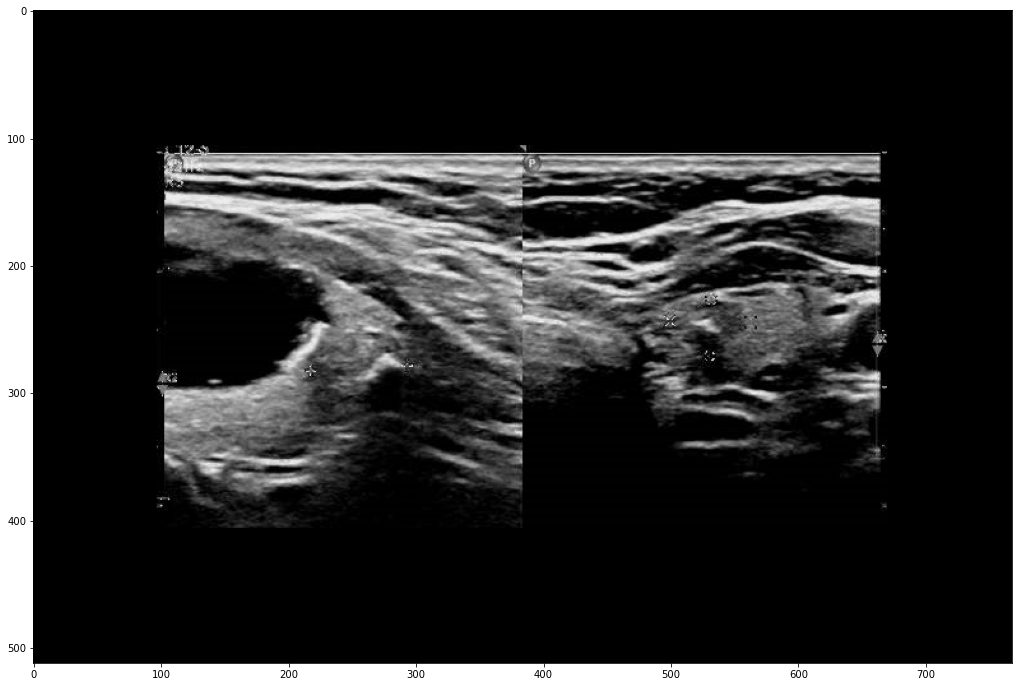

In [41]:
#display sample image
plt.imshow(x[0],'gray')
plt.show()

In [42]:
compo_score=df.compo_score
y=pd.DataFrame(compo_score).to_numpy()

# ❗BEWARE❗ 
1. THIS NEXT CELL CHANGES INPUT Y LABELS AND OUTPUT Y LABELS; SO NEED TO CHANGE OUTPUT Y LABELS ACCORDINGLY. 
2. CHANGE ACCORDINGLY AS WELL WHEN POSSIBLE Y LABELS FOR COMPOSITION INCREASES FROM 2 TO 3. (with the inclusion of 0 points category)

❗❗❗

In [43]:
#THIS CELL
y=y-1

In [44]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

train_ratio = 0.70
validation_ratio = 0.15
test_ratio = 0.15

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=1-train_ratio, random_state=43)

x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=test_ratio/(test_ratio + validation_ratio), random_state=43) 

In [45]:
x_train = tf.expand_dims(x_train, axis=-1)
x_val = tf.expand_dims(x_val, axis=-1)
x_test = tf.expand_dims(x_test, axis=-1)

In [46]:
print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)
print(x_test.shape)
print(y_test.shape)

(76, 512, 768, 1)
(76, 1)
(16, 512, 768, 1)
(16, 1)
(17, 512, 768, 1)
(17, 1)


# Train model

In [47]:
import tensorflow as tf
from tensorflow.keras.regularizers import l2

In [48]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.Conv2D(16, kernel_size=(5,5), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(32, kernel_size=(7,7), activation='relu'),
    tf.keras.layers.Conv2D(64, kernel_size=(7,7), activation='relu', kernel_regularizer=l2(0.01), bias_regularizer=l2(0.01)),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Flatten(), # Flattening the 2D arrays for fully connected layers
    # tf.keras.layers.Dropout(0.2), not rly useful
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [49]:
loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [50]:
model.compile(tf.keras.optimizers.Adam(learning_rate=1e-4), #gradient descent method(of the loss function)
              loss=loss_fn,
              metrics=['accuracy'])

# ❗❗ IMPORTANT TO NOTE ❗❗

There are 105 y labels with '2' and only 4 y labels with '1'
This likely explains the high accuracy for the data.
Just by predicting all y labels as '2', without through machine learning, high accuracy >90% (or even 100% if for example: there are no y labels with '1' in the evaluation set, and the algorithm just predicts the y label as '2', etc) can already be achieved.
Hence unreliable.
To slightly balance this out, I randomly shuffled the training data with a fixed seed, such that in the 4 y labels with '1': 2 are part of the training data, 1 is part of validation data, 1 in part of test data.

❗❗❗❗

In [51]:
from keras.callbacks import EarlyStopping
callback = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=2)

history=model.fit(x_train, y_train, epochs=20, batch_size=4, shuffle=True, validation_data=(x_val, y_val), callbacks=[callback])
#^put number of epochs as 3 to prevent overfitting, due to the small number of y labels with '1'.

Epoch 1/20
19/19 [==============================] - 219s 10s/step - loss: 0.7454 - accuracy: 0.9211 - val_loss: 0.6125 - val_accuracy: 0.9375
Epoch 2/20
19/19 [==============================] - 159s 8s/step - loss: 0.4950 - accuracy: 0.9737 - val_loss: 0.6019 - val_accuracy: 0.9375
Epoch 3/20
19/19 [==============================] - 145s 8s/step - loss: 0.4348 - accuracy: 0.9868 - val_loss: 0.6100 - val_accuracy: 0.9375
Epoch 4/20
19/19 [==============================] - 146s 8s/step - loss: 0.3780 - accuracy: 0.9868 - val_loss: 0.6434 - val_accuracy: 0.9375
Epoch 00004: early stopping


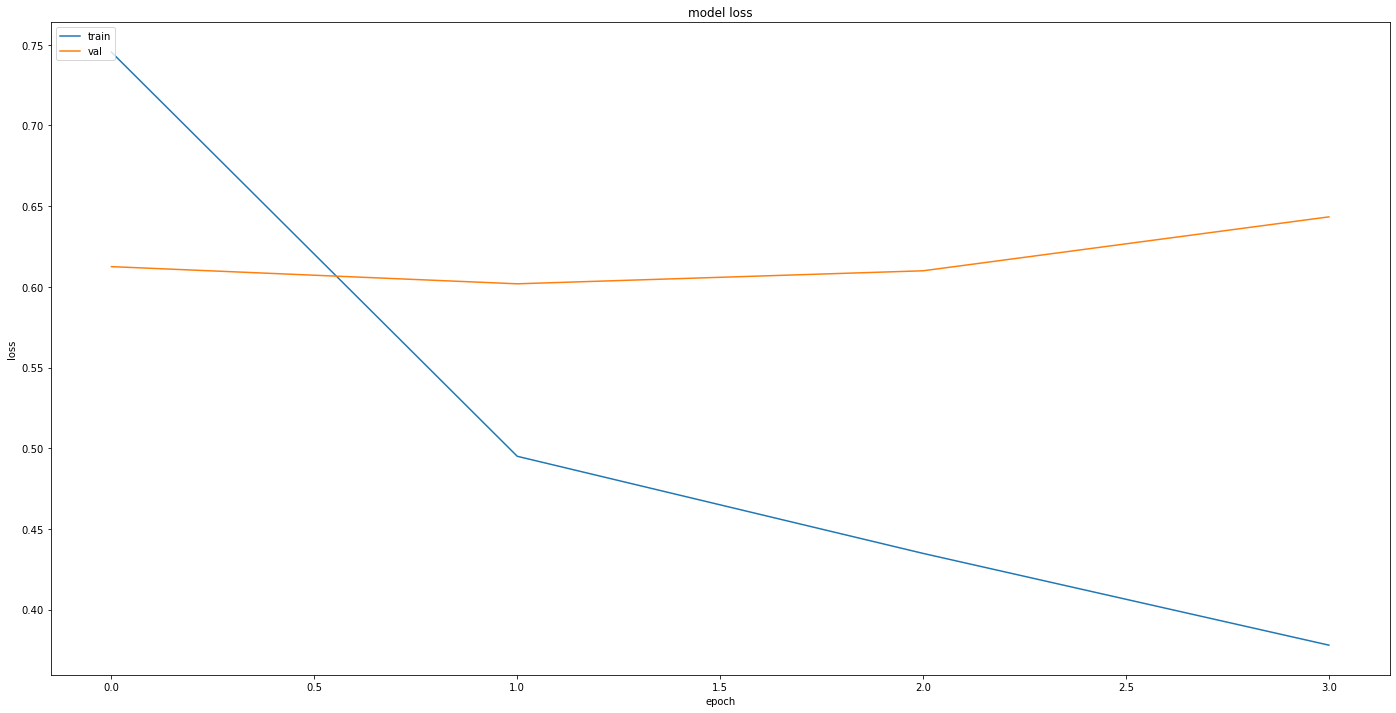

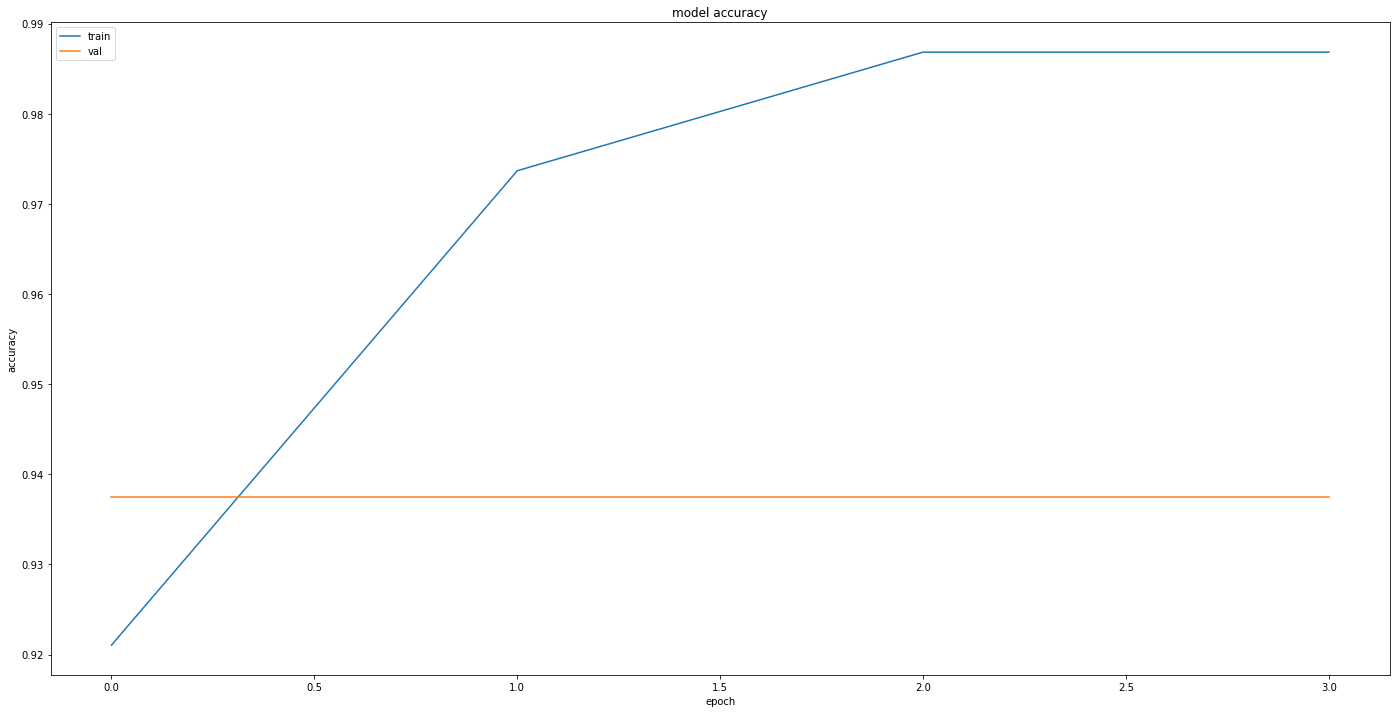

In [52]:
from matplotlib import pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left') 
plt.show()

# Evaluate model

In [53]:
model.evaluate(x_test,  y_test, verbose=2)

1/1 - 6s - loss: 0.6831 - accuracy: 0.9412


[0.683131992816925, 0.9411764740943909]